<a href="https://colab.research.google.com/github/mahadikprasad15/ARENA/blob/main/Truth_Probe_Generalization_Across_Hyperparameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

prasadmahadik_cities_path = kagglehub.dataset_download('prasadmahadik/cities')
prasadmahadik_companies_path = kagglehub.dataset_download('prasadmahadik/companies')
prasadmahadik_spanish_en_path = kagglehub.dataset_download('prasadmahadik/spanish-en')
prasadmahadik_counter_fact_path = kagglehub.dataset_download('prasadmahadik/counter-fact')
prasadmahadik_larger_than_path = kagglehub.dataset_download('prasadmahadik/larger-than')
prasadmahadik_common_claim_path = kagglehub.dataset_download('prasadmahadik/common-claim')

print('Data source import complete.')


# Setup files

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import datasets

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from tqdm import tqdm
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import os
import json
import pandas as pd
import gc

from google.colab import files
import io

from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Creating Training Data for Probe

In [ ]:
statements_data = [
    {"text": "The Earth is the third planet from the Sun.", "label": "truth"},
    {"text": "Humans can breathe underwater without any equipment.", "label": "lie"},
    {"text": "Water boils at 100 degrees Celsius at sea level.", "label": "truth"},
    {"text": "The moon is made of cheese.", "label": "lie"},
    {"text": "Birds are mammals.", "label": "lie"},
    {"text": "The capital of France is Paris.", "label": "truth"},
    {"text": "A square has five equal sides.", "label": "lie"},
    {"text": "The highest mountain in the world is Mount Everest.", "label": "truth"},
    {"text": "Fish can survive out of water for several hours.", "label": "lie"},
    {"text": "The Pacific Ocean is the largest ocean on Earth.", "label": "truth"},
    {"text": "Africa is the largest continent on Earth.", "label": "truth"},
    {"text": "Gold is a non-metal.", "label": "lie"},
    {"text": "Issac Newton discovered the law of gravity", "label" : "truth"},
    {"text": "The Machinist is a movie starring Leonardo DiCaprio", "label": "lie"},
    {"text": "Gold is the most costly metal.", "label": "lie"},
    {"text": "The Pacific Ocean is the largest ocean on Earth.", "label": "truth"},
    {"text": "Bread is baked in a quarry.", "label": "lie"},
    {"text": "Electricity is due to flow of electrons.", "label": "truth"},
    {"text": "Mathematics is the study of fish stews over the world", "label": "lie"},
    {"text": "Sachin Tendulkar has the highest runs in Cricket", "label": "truth"}
]

## Downoading Model

In [ ]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

2025-12-24 12:25:38.080696: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766579138.255724      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766579138.310685      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766579138.740137      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766579138.740172      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766579138.740175      55 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

## Creating the probes for all layers from Difference In Means

In [ ]:
truth_text_data = [data['text']for data in statements_data if data['label'] == 'truth']
lie_text_data = [data['text']for data in statements_data if data['label'] == 'lie']

truth_label =  [data['label']for data in statements_data if data['label'] == 'truth']
lie_label =  [data['label']for data in statements_data if data['label'] == 'truth']

truth_tokens = tokenizer(truth_text_data, padding = True)
lie_tokens = tokenizer(lie_text_data, padding = True)

truth_token_tensors = torch.tensor(truth_tokens['input_ids'], device = device)
lie_token_tensors = torch.tensor(lie_tokens['input_ids'], device = device)

truth_output = model(truth_token_tensors, output_hidden_states = True)
lie_output = model(lie_token_tensors, output_hidden_states = True)


layer_outputs_truth = torch.stack(truth_output.hidden_states, dim = 0) # [layer, batch, seq, d_model]
layer_outputs_lie = torch.stack(lie_output.hidden_states, dim = 0) # [layer, batch, seq, d_model]

In [ ]:
layer_outputs_truth_mean = layer_outputs_truth.mean(dim = (1,2))
layer_outputs_lie_mean = layer_outputs_lie.mean(dim = (1,2))

In [ ]:
probes_by_layer = layer_outputs_truth_mean - layer_outputs_lie_mean

In [ ]:
uploaded = files.upload()



In [ ]:
file_bytes = uploaded['cities (2).csv']

In [ ]:
test_db = pd.read_csv('/kaggle/input/cities/cities.csv')

In [ ]:
test_statements = list(test_db['statement'])
test_labels = list(test_db['label'])

In [ ]:
test_tokens = tokenizer(test_statements, padding = True)
test_token_tensor = torch.tensor(test_tokens['input_ids'], device = device)

with torch.no_grad():  # This prevents gradient storage
  test_activations = model(test_token_tensor, output_hidden_states = True).hidden_states

In [ ]:
test_activations_layers = torch.stack(test_activations, dim = 0)
probes_by_layer = probes_by_layer.unsqueeze(1).unsqueeze(1)

probe_scores = (test_activations_layers * probes_by_layer).sum(dim=-1)

probe_scores = probe_scores.mean(dim=-1)


In [ ]:
probe_scores_np = probe_scores.detach().cpu().float().numpy()
test_labels_np = np.array(test_labels)

for layer in range(probe_scores_np.shape[0]):
    auroc = roc_auc_score(test_labels_np, probe_scores_np[layer])
    print(f"Layer {layer}: AUROC = {auroc:.3f}")

The AUROC scores were pretty bad for all the layers - and it seems that the clear reason for this is that the truth and lie facts don't have counterfactuals for the probes to capture the difference of. Without the counterfactuals - the probe is probably capturing things that are semantic..

The solution would be -
I have the cities dataset - and it has clear counterfactual pairs - so, create general purpose function that extracts the activations, and another that gets the probes from the activations and their differences.


In [ ]:
def get_activations(model, tokenizer, texts, device, batch_size=8):
    """
    Get activations for a list of texts.

    Args:
        model: The language model
        tokenizer: The tokenizer
        texts: List of strings
        device: 'cuda' or 'cpu'
        batch_size: Number of texts to process at once

    Returns:
        torch.Tensor of shape [n_layers, n_samples, seq_len, d_model]
    """

    all_tokens = tokenizer(texts, padding='longest', return_tensors='pt')
    max_len = all_tokens['input_ids'].shape[1]

    all_activations = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc = 'Getting batched activations'):
            batch_texts = texts[i:i+batch_size]
            # Pad to the global max length
            tokens = tokenizer(batch_texts, padding='max_length', max_length=max_len, return_tensors='pt')
            token_ids = tokens['input_ids'].to(device)

            output = model(token_ids, output_hidden_states=True)
            batch_activations = torch.stack(output.hidden_states, dim=0)
            all_activations.append(batch_activations)

            del token_ids, output
            torch.cuda.empty_cache()

    # Now all batches have same seq_len, concatenation works!
    return torch.cat(all_activations, dim=1)


def compute_mean_activations(activations, labels, label_value):
    """
    Compute mean activations for samples with specific label.

    Args:
        activations: [n_layers, n_samples, seq, d_model]
        labels: List of labels corresponding to samples
        label_value: The label to filter by (e.g., 'truth', 1, etc.)

    Returns:
        torch.Tensor of shape [n_layers, 1, 1, d_model]
    """
    # Find indices matching the label
    label_indices = [i for i, label in enumerate(labels) if label == label_value]


    filtered = activations[:, label_indices, :, :]
    mean_activations = filtered.mean(dim=(1, 2), keepdim=True)

    return mean_activations


def create_difference_probe(truth_mean, lie_mean):
    """
    Create difference-of-means probe.

    Args:
        truth_mean: [n_layers, 1, 1, d_model]
        lie_mean: [n_layers, 1, 1, d_model]

    Returns:
        probe: [n_layers, 1, 1, d_model]
    """
    return truth_mean - lie_mean


def evaluate_probe(probe, test_activations, test_labels):

    from sklearn.metrics import roc_auc_score

    binary_labels = [1 if label in ['truth', 1] else 0 for label in test_labels]

    # Do multiplication AND sum on GPU in one step
    scores = (test_activations * probe).sum(dim=-1).mean(dim=-1)

    # Move small tensor to CPU
    scores_np = scores.float().cpu().numpy()

    # Clear GPU immediately
    del test_activations, probe, scores
    torch.cuda.empty_cache()

    results = {}
    for layer in range(scores_np.shape[0]):
        auroc = roc_auc_score(binary_labels, scores_np[layer])
        results[layer] = auroc

    return results

def train_probe(texts, labels, label_values, model, tokenizer):
    label_value_lie = label_values[0]
    label_value_truth = label_values[1]
    train_activations = get_activations(model, tokenizer, texts, device, batch_size=8)
    lie_mean = compute_mean_activations(train_activations, labels = labels, label_value = label_value_lie)
    truth_mean = compute_mean_activations(train_activations, labels = labels, label_value = label_value_truth)
    probe = create_difference_probe(truth_mean, lie_mean)

    return probe

def evaluate_probe_on_text(probe, test_texts, test_labels, model, tokenizer):

    test_activations = get_activations(model, tokenizer, test_texts, device, batch_size=8)

    binary_labels = [1 if label in ['truth', 1] else 0 for label in test_labels]

    # Do multiplication AND sum on GPU in one step
    scores = (test_activations * probe).sum(dim=-1).mean(dim=-1)

    # Move small tensor to CPU
    scores_np = scores.float().cpu().numpy()

    # Clear GPU immediately
    del test_activations, probe, scores
    torch.cuda.empty_cache()

    results = {}
    for layer in range(scores_np.shape[0]):
        auroc = roc_auc_score(binary_labels, scores_np[layer])
        results[layer] = auroc

    return results

def compute_probe_from_activations(activations, labels):
    """Compute probe from pre-computed activations"""
    lie_mean = compute_mean_activations(activations, labels, 0)
    truth_mean = compute_mean_activations(activations, labels, 1)
    probe = create_difference_probe(truth_mean, lie_mean)
    return probe



def evaluate_probe_on_activations(probe, activations, labels):
    """Evaluate using pre-computed activations"""
    binary_labels = [1 if label in ['truth', 1] else 0 for label in labels]

    scores = (activations * probe).sum(dim=-1).mean(dim=-1)
    scores_np = scores.float().cpu().numpy()

    results = {}
    for layer in range(scores_np.shape[0]):
        auroc = roc_auc_score(binary_labels, scores_np[layer])
        results[layer] = auroc

    return results

In [ ]:
texts = list(test_db['statement'])
labels = list(test_db['label'])
labels = list(map(lambda x: int(x), labels))

label_value_truth = 1
label_value_lie = 0
label_values = [label_value_lie, label_value_truth]

probe = train_probe(texts, labels, label_values, model, tokenizer)

In [ ]:
uploaded = files.upload()

In [ ]:
file_bytes = uploaded['companies_true_false.csv']
true_test_db = pd.read_csv(io.BytesIO(file_bytes))

In [ ]:
true_test_db = pd.read_csv('/kaggle/input/companies/companies_true_false.csv')
test_texts = list(true_test_db['statement'])
test_labels = list(true_test_db['label'])

test_activations = get_activations(model, tokenizer, test_texts, device, batch_size=8)

In [ ]:
results = evaluate_probe(probe, test_activations, test_labels)
for layer, auroc in results.items():
    print(f'Layer {layer} AUROC ---> {auroc :.2f}')

Now that we have good pipeline of training probes, evaluation and related functions, we can sweep through datasets, and find evaluation scores for different combination of probes.

So, I should take in a list of paths, and create dbs, then create texts, and create labels and label_values - this could be called get_all_data -> texts, labels, label_values
should this be a dict or a list?
I think it should be a dict - clear and no confusion.

then I should have another function that trains on db, and another that evaluates and finds its best probe. After this, things can be thrown..this can be repeated for a probe, and all



In [ ]:
def load_datasets(datasets_paths):
    """
    Args:
        dataset_paths: dict like {'cities': 'path/to/cities.csv', 'companies': ...}

    Returns:
        dict: {
            'cities': {'texts': [...], 'labels': [0,1,0,...]},
            'companies': {'texts': [...], 'labels': [0,1,1,...]},
            ...
        }
    """
    datasets_dict = {}

    for dataset_name, path in datasets_paths.items():
        db = pd.read_csv(path)
        db_text = list(db['statement'])
        db_label = list(db['label'])
        datasets_dict[dataset_name] = {'texts': db_text,
                                     'labels':db_label}
    return datasets_dict

In [ ]:
datasets_paths = {'spanish_db':'/kaggle/input/spanish-en/sp_en_trans.csv',
                'common_claim_db':'/kaggle/input/common-claim/common_claim_true_false.csv',
                'counter_fact_db' :'/kaggle/input/counter-fact/counterfact_true_false.csv',
                'larger_than_db' : '/kaggle/input/larger-than/larger_than.csv',
                'cities_db' : '/kaggle/input/cities/cities.csv',
                'companies_db' : '/kaggle/input/companies/companies_true_false.csv',
                }

datasets_dict = load_datasets(datasets_paths)

In [ ]:
def compute_probe_streaming(texts, labels, model, tokenizer, batch_size=8):
    """
    Compute probe using streaming/incremental mean calculation.
    Never stores all activations at once!
    """

    truth_sum = None
    lie_sum = None
    truth_count = 0
    lie_count = 0


    all_tokens = tokenizer(texts, padding='longest', return_tensors='pt')
    max_len = all_tokens['input_ids'].shape[1]
    del all_tokens

    # Process in batches
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc='Computing probe'):
            # Get batch
            batch_texts = texts[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]


            tokens = tokenizer(batch_texts, padding='max_length', max_length=max_len, return_tensors='pt')
            token_ids = tokens['input_ids'].to(device)
            output = model(token_ids, output_hidden_states=True)
            batch_activations = torch.stack(output.hidden_states, dim=0)  # [n_layers, batch, seq, d_model]

            # Split by label and accumulate
            for idx, label in enumerate(batch_labels):
                # Get activations for this sample: [n_layers, seq, d_model]
                sample_act = batch_activations[:, idx, :, :]

                if label == 1:  # truth
                    if truth_sum is None:
                        truth_sum = sample_act.sum(dim=1)  # Sum over sequence: [n_layers, d_model]
                    else:
                        truth_sum += sample_act.sum(dim=1)
                    truth_count += sample_act.shape[1]  # Add sequence length
                else:  # lie
                    if lie_sum is None:
                        lie_sum = sample_act.sum(dim=1)
                    else:
                        lie_sum += sample_act.sum(dim=1)
                    lie_count += sample_act.shape[1]

            # Clean up batch
            del token_ids, output, batch_activations
            torch.cuda.empty_cache()

    # Compute final means
    truth_mean = (truth_sum / truth_count).unsqueeze(1).unsqueeze(1)  # [n_layers, 1, 1, d_model]
    lie_mean = (lie_sum / lie_count).unsqueeze(1).unsqueeze(1)

    probe = truth_mean - lie_mean
    return probe

def evaluate_probe_streaming(probe, texts, labels, model, tokenizer, batch_size=8):
    """
    Evaluate probe using streaming - never stores all activations at once
    """

    all_tokens = tokenizer(texts, padding='longest', return_tensors='pt')
    max_len = all_tokens['input_ids'].shape[1]
    del all_tokens

    n_layers = probe.shape[0]
    all_scores = [[] for _ in range(n_layers)]
    binary_labels = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc='Evaluating'):
            batch_texts = texts[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]


            tokens = tokenizer(batch_texts, padding='max_length', max_length=max_len, return_tensors='pt')
            token_ids = tokens['input_ids'].to(device)
            output = model(token_ids, output_hidden_states=True)
            batch_activations = torch.stack(output.hidden_states, dim=0)

            # Compute scores for this batch
            batch_scores = (batch_activations * probe).sum(dim=-1).mean(dim=-1)  # [n_layers, batch]

            # Accumulate scores per layer
            for layer in range(n_layers):
                all_scores[layer].extend(batch_scores[layer].cpu().float().numpy().tolist())

            binary_labels.extend([1 if label in ['truth', 1] else 0 for label in batch_labels])


            del token_ids, output, batch_activations, batch_scores
            torch.cuda.empty_cache()

    # Compute AUROC for each layer
    results = {}
    for layer in range(n_layers):
        auroc = roc_auc_score(binary_labels, all_scores[layer])
        results[layer] = auroc

    return results


def train_all_probes(datasets, model, tokenizer, batch_size=8):
    """Train all probes using streaming computation"""
    probes = {}

    for dataset_name, data in datasets.items():
        print(f'\nTraining probe on {dataset_name}')


        probe = compute_probe_streaming(
            data['texts'],
            data['labels'],
            model,
            tokenizer,
            batch_size=batch_size
        )


        print('Evaluating on same dataset')
        layer_aurocs = evaluate_probe_streaming(
            probe,
            data['texts'],
            data['labels'],
            model,
            tokenizer,
            batch_size=batch_size
        )

        best_layer = max(layer_aurocs, key=layer_aurocs.get)
        print(f'Best layer: {best_layer}, AUROC: {layer_aurocs[best_layer]:.3f}')

        # Store full probe (all layers) + best layer info
        probes[dataset_name] = {
            'probe': probe,
            'best_layer': best_layer,
            'train_auroc': layer_aurocs[best_layer]
        }

        # Cleanup
        del probe, layer_aurocs
        torch.cuda.empty_cache()
        gc.collect()

    return probes

In [ ]:
all_probes = train_all_probes(datasets_dict, model, tokenizer, batch_size=8)


Training probe on spanish_db


Computing probe: 100%|██████████| 45/45 [00:03<00:00, 12.76it/s]


Evaluating on same dataset


Evaluating: 100%|██████████| 45/45 [00:03<00:00, 14.86it/s]


Best layer: 12, AUROC: 0.990

Training probe on common_claim_db


...

Best layer: 17, AUROC: 0.897

Training probe on companies_db


Computing probe: 100%|██████████| 150/150 [00:16<00:00,  9.15it/s]


Evaluating on same dataset


Evaluating: 100%|██████████| 150/150 [00:16<00:00,  9.03it/s]


Best layer: 12, AUROC: 0.705


In [ ]:
def evaluate_probe_on_all_datasets(
    train_dataset_name,  # which probe to use
    probes,              # the full probes dict
    datasets,            # all test datasets
    model,
    tokenizer,
    batch_size=8
):
    """
    Take ONE probe (trained on train_dataset_name) and evaluate it across ALL datasets.
    Returns generalization results for this single probe.
    """

    probe_info = probes[train_dataset_name]
    probe = probe_info['probe']  # shape: [n_layers, 1, 1, d_model]


    results = {
        'train_dataset': train_dataset_name,
        'train_best_layer': probe_info['best_layer'],
        'train_auroc': probe_info['train_auroc'],
        'test_results': {}
    }


    for test_dataset_name, test_data in datasets.items():
        print(f'\nTesting {train_dataset_name} probe on {test_dataset_name}')

        layer_aurocs = evaluate_probe_streaming(probe, test_data['texts'], test_data['labels'], model, tokenizer, batch_size=8)
        best_layer = sorted(layer_aurocs.items(), key = lambda x: x[1], reverse = True)[0][0]
        best_layer_auroc = sorted(layer_aurocs.items(), key = lambda x: x[1], reverse = True)[0][1]

        print(f'Test performance on {test_dataset_name}: Best Layer - {best_layer}, auroc {best_layer_auroc: .2f}')

        results['test_results'][test_dataset_name] = {'best_layer': best_layer,
                                                      'auroc': best_layer_auroc
                                                     }


    return results

In [ ]:
cities_db_test = evaluate_probe_on_all_datasets('cities_db',
                                                all_probes,
                                                datasets_dict,
                                                model,
                                                tokenizer,
                                                batch_size=8
                                                )


Testing cities_db probe on spanish_db


Evaluating: 100%|██████████| 45/45 [00:03<00:00, 14.79it/s]


Test performance on spanish_db: Best Layer - 17, auroc 0.6844297615627695

Testing cities_db probe on common_claim_db


Evaluating: 100%|██████████| 557/557 [00:46<00:00, 12.03it/s]


Test performance on common_claim_db: Best Layer - 9, auroc 0.574905592728191

Testing cities_db probe on counter_fact_db


...

Test performance on larger_than_db: Best Layer - 9, auroc 0.6068579736761555

Testing cities_db probe on cities_db


Evaluating: 100%|██████████| 187/187 [00:15<00:00, 12.18it/s]


Test performance on cities_db: Best Layer - 17, auroc 0.8968407732563127

Testing cities_db probe on companies_db


Evaluating: 100%|██████████| 150/150 [00:16<00:00,  8.94it/s]

Test performance on companies_db: Best Layer - 9, auroc 0.5923847222222223


In [ ]:
cities_db_test

{'train_dataset': 'cities_db',
 'train_best_layer': 17,
 'train_auroc': np.float64(0.8968407732563127),
 'test_results': {'spanish_db': {'best_layer': 17,
   'auroc': np.float64(0.6844297615627695)},
  'common_claim_db': {'best_layer': 9, 'auroc': np.float64(0.574905592728191)},
  'counter_fact_db': {'best_layer': 17,
   'auroc': np.float64(0.5510962789119489)},
  'larger_than_db': {'best_layer': 9, 'auroc': np.float64(0.6068579736761555)},
  'cities_db': {'best_layer': 17, 'auroc': np.float64(0.8968407732563127)},
  'companies_db': {'best_layer': 9, 'auroc': np.float64(0.5923847222222223)}}}

In [ ]:
companies_db_test = evaluate_probe_on_all_datasets(
                                                    'companies_db',
                                                    all_probes,
                                                    datasets_dict,
                                                    model,
                                                    tokenizer,
                                                    batch_size=8
                                                )


Testing companies_db probe on spanish_db


Evaluating: 100%|██████████| 45/45 [00:03<00:00, 14.89it/s]


Test performance on spanish_db: Best Layer - 13, auroc 0.7128060263653484

Testing companies_db probe on common_claim_db


Evaluating: 100%|██████████| 557/557 [00:46<00:00, 12.05it/s]


Test performance on common_claim_db: Best Layer - 13, auroc 0.6276872112107058

Testing companies_db probe on counter_fact_db


...

Test performance on larger_than_db: Best Layer - 24, auroc 0.7155989184777065

Testing companies_db probe on cities_db


Evaluating: 100%|██████████| 187/187 [00:15<00:00, 12.18it/s]


Test performance on cities_db: Best Layer - 14, auroc 0.8110871414681575

Testing companies_db probe on companies_db


Evaluating: 100%|██████████| 150/150 [00:16<00:00,  8.95it/s]

Test performance on companies_db: Best Layer - 12, auroc 0.7045902777777777


In [ ]:
larger_than_db_test = evaluate_probe_on_all_datasets(
                                                    'larger_than_db',
                                                    all_probes,
                                                    datasets_dict,
                                                    model,
                                                    tokenizer,
                                                    batch_size=8
                                                )


Testing larger_than_db probe on spanish_db


Evaluating: 100%|██████████| 45/45 [00:03<00:00, 14.80it/s]


Test performance on spanish_db: Best Layer - 14, auroc 0.602189664528073

Testing larger_than_db probe on common_claim_db


Evaluating: 100%|██████████| 557/557 [00:46<00:00, 12.04it/s]


Test performance on common_claim_db: Best Layer - 13, auroc 0.5854038631485924

Testing larger_than_db probe on counter_fact_db


...

Test performance on larger_than_db: Best Layer - 1, auroc 0.8499183756759514

Testing larger_than_db probe on cities_db


Evaluating: 100%|██████████| 187/187 [00:15<00:00, 12.17it/s]


Test performance on cities_db: Best Layer - 13, auroc 0.5539692298893307

Testing larger_than_db probe on companies_db


Evaluating: 100%|██████████| 150/150 [00:16<00:00,  8.95it/s]

Test performance on companies_db: Best Layer - 24, auroc 0.5302541666666666


In [ ]:
spanish_db_test = evaluate_probe_on_all_datasets(
                                                    'spanish_db',
                                                    all_probes,
                                                    datasets_dict,
                                                    model,
                                                    tokenizer,
                                                    batch_size=8
                                                )


Testing spanish_db probe on spanish_db


Evaluating: 100%|██████████| 45/45 [00:03<00:00, 14.93it/s]


Test performance on spanish_db: Best Layer - 12, auroc 0.98957834594146

Testing spanish_db probe on common_claim_db


Evaluating: 100%|██████████| 557/557 [00:46<00:00, 12.03it/s]


Test performance on common_claim_db: Best Layer - 12, auroc 0.6296782729453352

Testing spanish_db probe on counter_fact_db


...

Test performance on larger_than_db: Best Layer - 22, auroc 0.6908050198959289

Testing spanish_db probe on cities_db


Evaluating: 100%|██████████| 187/187 [00:15<00:00, 12.20it/s]


Test performance on cities_db: Best Layer - 12, auroc 0.7934688581314879

Testing spanish_db probe on companies_db


Evaluating: 100%|██████████| 150/150 [00:16<00:00,  8.94it/s]

Test performance on companies_db: Best Layer - 16, auroc 0.6005055555555556


In [ ]:
common_claim_db_test = evaluate_probe_on_all_datasets(
                                                    'common_claim_db',
                                                    all_probes,
                                                    datasets_dict,
                                                    model,
                                                    tokenizer,
                                                    batch_size=8
                                                )


Testing common_claim_db probe on spanish_db


Evaluating: 100%|██████████| 45/45 [00:03<00:00, 14.75it/s]


Test performance on spanish_db: Best Layer - 13, auroc 0.5999233936608255

Testing common_claim_db probe on common_claim_db


Evaluating: 100%|██████████| 557/557 [00:46<00:00, 12.06it/s]


Test performance on common_claim_db: Best Layer - 15, auroc 0.6412952909986113

Testing common_claim_db probe on counter_fact_db


...

Test performance on larger_than_db: Best Layer - 2, auroc 0.8048801142740537

Testing common_claim_db probe on cities_db


Evaluating: 100%|██████████| 187/187 [00:15<00:00, 12.19it/s]


Test performance on cities_db: Best Layer - 24, auroc 0.548134597786611

Testing common_claim_db probe on companies_db


Evaluating: 100%|██████████| 150/150 [00:16<00:00,  8.93it/s]

Test performance on companies_db: Best Layer - 23, auroc 0.5220652777777778


In [ ]:
counter_fact_db_test = evaluate_probe_on_all_datasets(
                                                    'counter_fact_db',
                                                    all_probes,
                                                    datasets_dict,
                                                    model,
                                                    tokenizer,
                                                    batch_size=8
                                                )


Testing counter_fact_db probe on spanish_db


Evaluating: 100%|██████████| 45/45 [00:03<00:00, 14.78it/s]


Test performance on spanish_db: Best Layer - 12, auroc 0.7944077372402566

Testing counter_fact_db probe on common_claim_db


Evaluating: 100%|██████████| 557/557 [00:46<00:00, 12.06it/s]


Test performance on common_claim_db: Best Layer - 13, auroc 0.5807744476707487

Testing counter_fact_db probe on counter_fact_db


...

Test performance on larger_than_db: Best Layer - 12, auroc 0.5391296806448321

Testing counter_fact_db probe on cities_db


Evaluating: 100%|██████████| 187/187 [00:15<00:00, 12.21it/s]


Test performance on cities_db: Best Layer - 12, auroc 0.737684627813206

Testing counter_fact_db probe on companies_db


Evaluating: 100%|██████████| 150/150 [00:16<00:00,  8.94it/s]

Test performance on companies_db: Best Layer - 12, auroc 0.5508430555555555


In [ ]:
results = {
    'larger_than_db': larger_than_db_test,
    'cities_db': cities_db_test,
    'companies_db': companies_db_test,
    'spanish_db': spanish_db_test,
    'common_claim_db': common_claim_db_test,
    'counter_fact_db': counter_fact_db_test
}

In [ ]:
def plot_generalization_heatmap(results, figsize=(10, 8)):
    """
    1. Generalization Matrix/Heatmap
    Rows = train dataset, Cols = test dataset
    """
    dataset_names = list(results.keys())
    n = len(dataset_names)

    # Build matrix
    matrix = np.zeros((n, n))
    for i, train_name in enumerate(dataset_names):
        for j, test_name in enumerate(dataset_names):
            matrix[i, j] = results[train_name]['test_results'][test_name]['auroc']

    # Clean names for display
    clean_names = [name.replace('_db', '') for name in dataset_names]

    # Plot
    plt.figure(figsize=figsize)
    sns.heatmap(matrix, annot=True, fmt='.2f',
                xticklabels=clean_names,
                yticklabels=clean_names,
                cmap='RdYlGn', vmin=0.5, vmax=1.0,
                cbar_kws={'label': 'AUROC'})
    plt.xlabel('Test Dataset', fontsize=12)
    plt.ylabel('Train Dataset', fontsize=12)
    plt.title('Probe Generalization Matrix\n(Diagonal = Self-Performance)', fontsize=14, pad=20)
    plt.tight_layout()
    return matrix


def plot_generalization_scores(results, figsize=(10, 6)):
    """
    2. Probe Generalization Ranking
    Average AUROC on OTHER datasets (excluding self)
    """
    gen_scores = {}
    self_scores = {}

    for train_name, result in results.items():
        # Self performance
        self_scores[train_name] = result['train_auroc']

        # Generalization = average on others
        other_aurocs = [v['auroc'] for k, v in result['test_results'].items()
                        if k != train_name]
        gen_scores[train_name] = np.mean(other_aurocs)

    # Clean names
    clean_names = [name.replace('_db', '') for name in gen_scores.keys()]

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(clean_names))
    width = 0.35

    bars1 = ax.bar(x - width/2, [self_scores[k] for k in gen_scores.keys()],
                   width, label='Self-Performance', alpha=0.8)
    bars2 = ax.bar(x + width/2, list(gen_scores.values()),
                   width, label='Avg on Others', alpha=0.8)

    ax.set_xlabel('Probe (Trained on)', fontsize=12)
    ax.set_ylabel('AUROC', fontsize=12)
    ax.set_title('Probe Self-Performance vs Generalization', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(clean_names, rotation=45, ha='right')
    ax.legend()
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylim([0.45, 1.0])

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    return gen_scores


def plot_layer_consistency(results, figsize=(12, 6)):
    """
    3. Layer Consistency Analysis
    Which layers work best for each probe-dataset pair?
    """
    data = []

    for train_name, result in results.items():
        for test_name, test_result in result['test_results'].items():
            data.append({
                'probe': train_name.replace('_db', ''),
                'test_dataset': test_name.replace('_db', ''),
                'best_layer': test_result['best_layer'],
                'auroc': test_result['auroc']
            })

    df = pd.DataFrame(data)

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Left: Heatmap of best layers
    pivot_layers = df.pivot(index='probe', columns='test_dataset', values='best_layer')
    sns.heatmap(pivot_layers, annot=True, fmt='.0f', cmap='viridis',
                ax=ax1, cbar_kws={'label': 'Best Layer'})
    ax1.set_title('Best Layer for Each Probe-Dataset Pair')
    ax1.set_xlabel('Test Dataset')
    ax1.set_ylabel('Probe')

    # Right: Layer distribution
    ax2.hist(df['best_layer'], bins=range(0, 33), alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Layer Number', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution of Best Layers')
    ax2.axvline(x=df['best_layer'].median(), color='red',
                linestyle='--', label=f'Median: {df["best_layer"].median():.0f}')
    ax2.legend()

    plt.tight_layout()
    return df


def plot_transfer_asymmetry(results, figsize=(10, 6)):
    """
    5. Asymmetric Transfer Analysis
    Compare A→B vs B→A transfer
    """
    dataset_names = list(results.keys())
    asymmetries = []

    for i, train_a in enumerate(dataset_names):
        for j, train_b in enumerate(dataset_names):
            if i < j:  # Only upper triangle
                # A trained, tested on B
                a_to_b = results[train_a]['test_results'][train_b]['auroc']
                # B trained, tested on A
                b_to_a = results[train_b]['test_results'][train_a]['auroc']

                asymmetry = abs(a_to_b - b_to_a)
                asymmetries.append({
                    'pair': f"{train_a.replace('_db', '')} ↔ {train_b.replace('_db', '')}",
                    'forward': a_to_b,
                    'backward': b_to_a,
                    'asymmetry': asymmetry
                })

    df = pd.DataFrame(asymmetries).sort_values('asymmetry', ascending=False)

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Left: Asymmetry magnitude
    ax1.barh(range(len(df)), df['asymmetry'], alpha=0.7)
    ax1.set_yticks(range(len(df)))
    ax1.set_yticklabels(df['pair'])
    ax1.set_xlabel('|AUROC_forward - AUROC_backward|', fontsize=11)
    ax1.set_title('Transfer Asymmetry by Dataset Pair')
    ax1.invert_yaxis()

    # Right: Forward vs Backward scatter
    ax2.scatter(df['forward'], df['backward'], s=100, alpha=0.6)
    ax2.plot([0.5, 1], [0.5, 1], 'r--', alpha=0.5, label='Perfect symmetry')
    for idx, row in df.iterrows():
        ax2.annotate(row['pair'], (row['forward'], row['backward']),
                    fontsize=8, alpha=0.7)
    ax2.set_xlabel('Forward Transfer AUROC', fontsize=11)
    ax2.set_ylabel('Backward Transfer AUROC', fontsize=11)
    ax2.set_title('Transfer Symmetry')
    ax2.legend()
    ax2.set_xlim([0.5, 1.0])
    ax2.set_ylim([0.5, 1.0])

    plt.tight_layout()
    return df


def create_full_report(results, save_path=None):
    """
    Generate all visualizations at once
    """
    print("Generating full probe analysis report...")

    print("\n1. Generalization Heatmap")
    matrix = plot_generalization_heatmap(results)
    plt.show()

    print("\n2. Generalization Scores")
    gen_scores = plot_generalization_scores(results)
    plt.show()
    print("\nGeneralization Scores:")
    for name, score in sorted(gen_scores.items(), key=lambda x: x[1], reverse=True):
        print(f"  {name}: {score:.3f}")

    print("\n3. Layer Consistency")
    layer_df = plot_layer_consistency(results)
    plt.show()

    print("\n4. Transfer Asymmetry")
    asym_df = plot_transfer_asymmetry(results)
    plt.show()
    print("\nMost Asymmetric Pairs:")
    print(asym_df.head())

    if save_path:
        print(f"\nSaving report to {save_path}")
        # Save summary stats
        summary = {
            'generalization_scores': gen_scores,
            'layer_stats': layer_df.groupby('probe')['best_layer'].describe(),
            'asymmetries': asym_df
        }
        # You can pickle or save as JSON here

    return {
        'gen_scores': gen_scores,
        'layer_df': layer_df,
        'asymmetry_df': asym_df,
        'matrix': matrix
    }


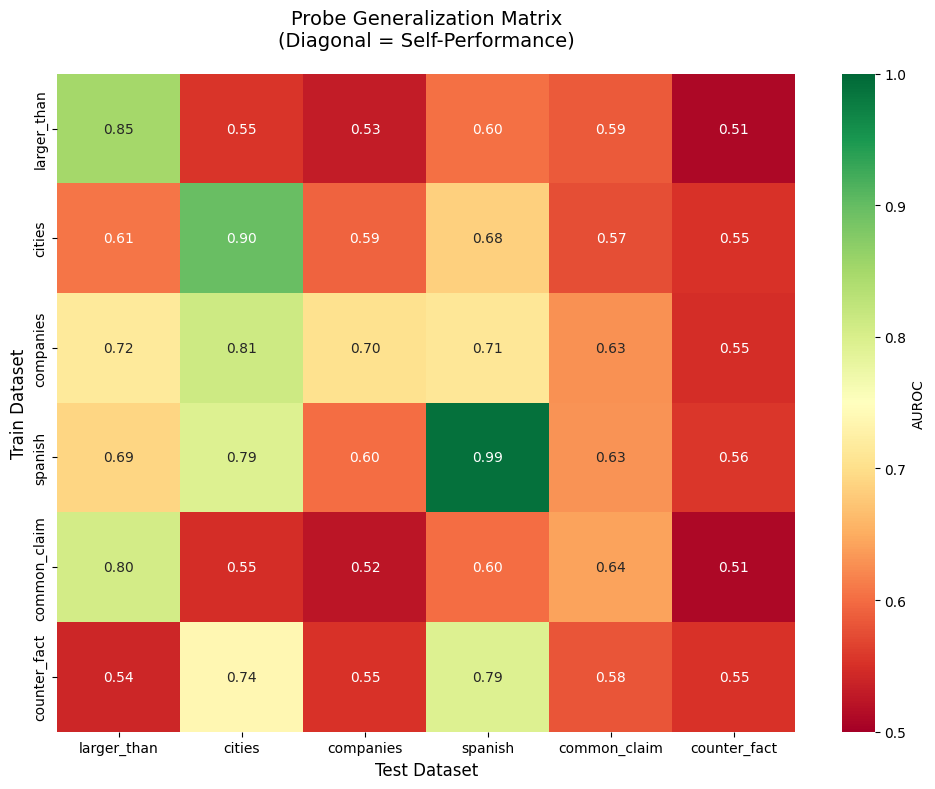

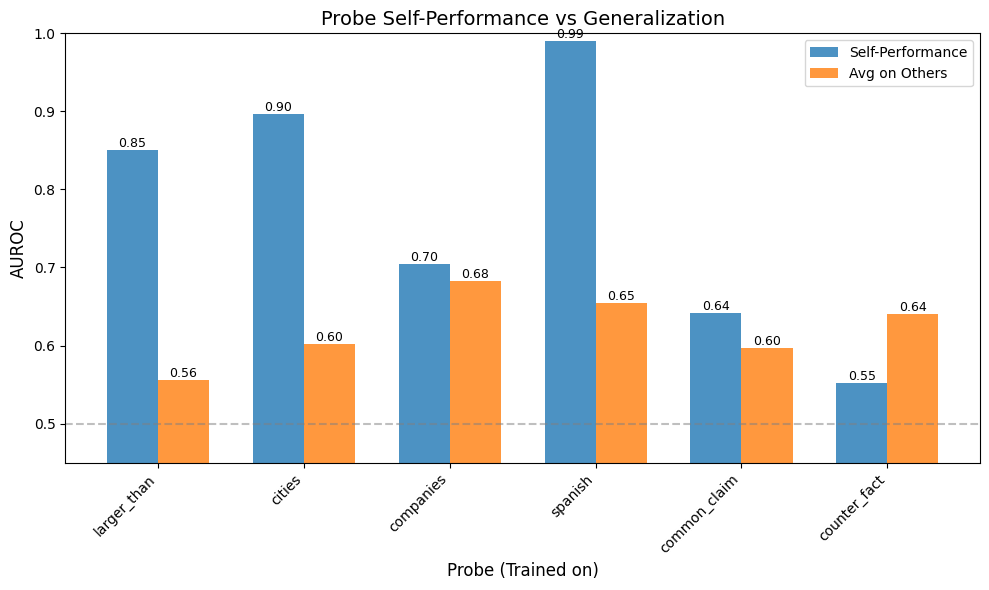

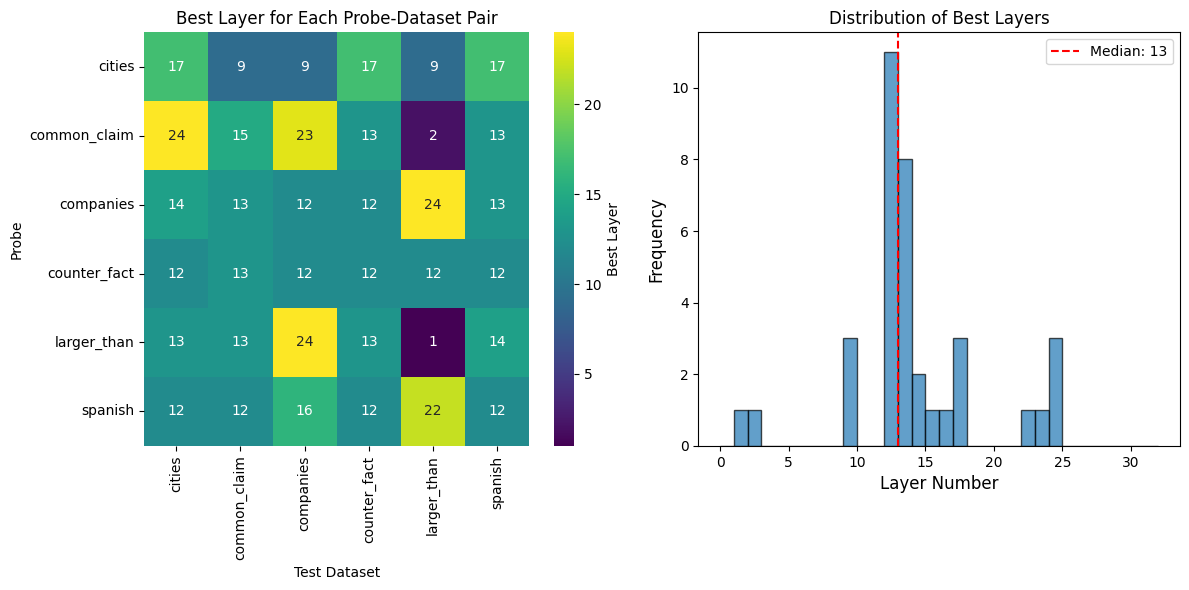

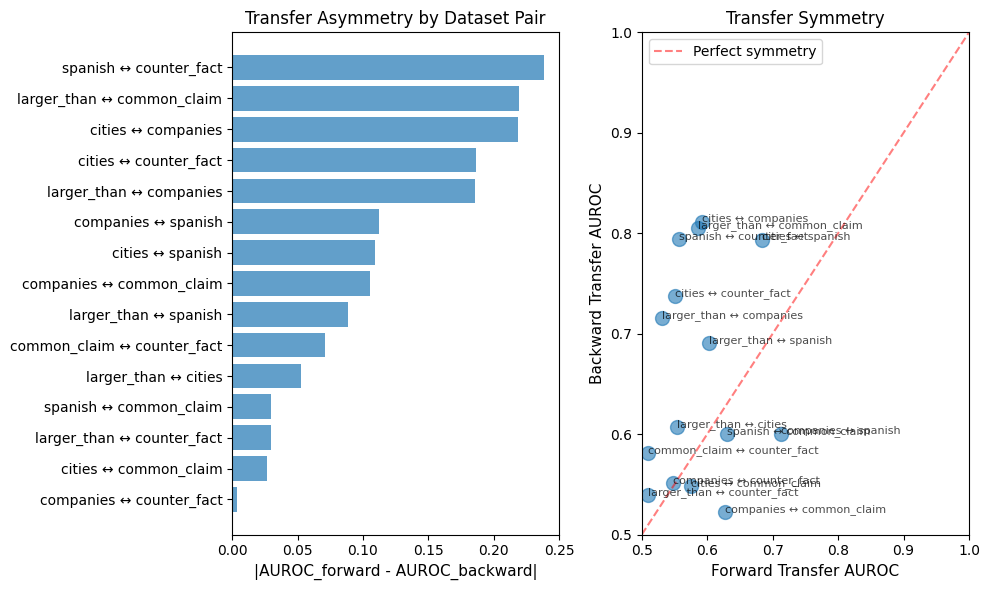

Generating full probe analysis report...

1. Generalization Heatmap


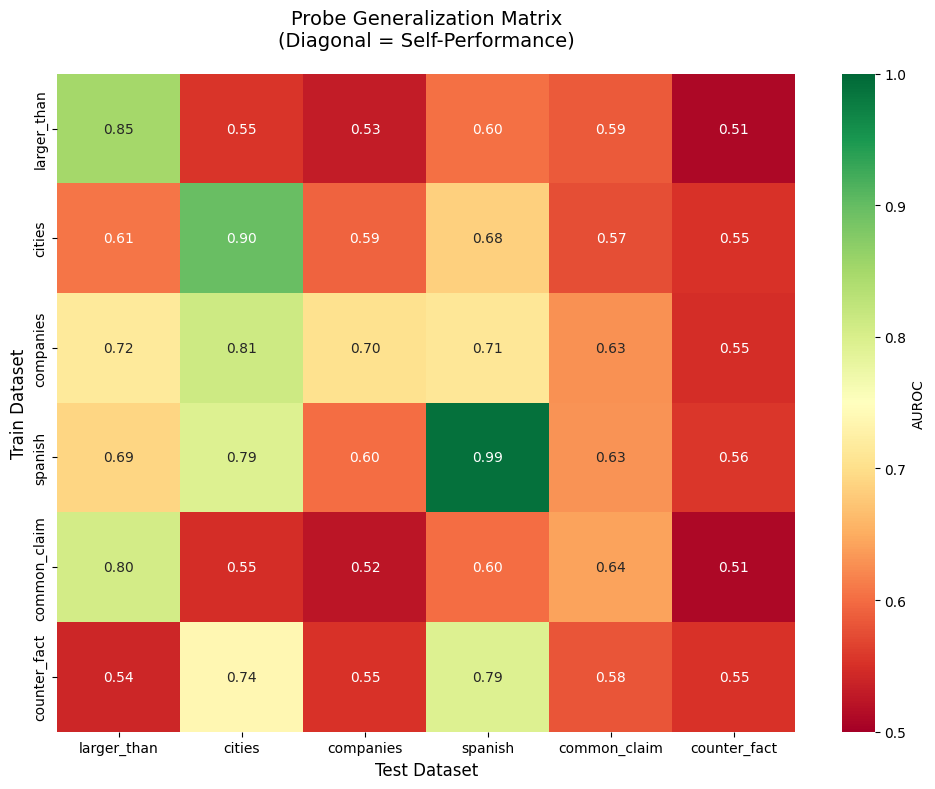


2. Generalization Scores


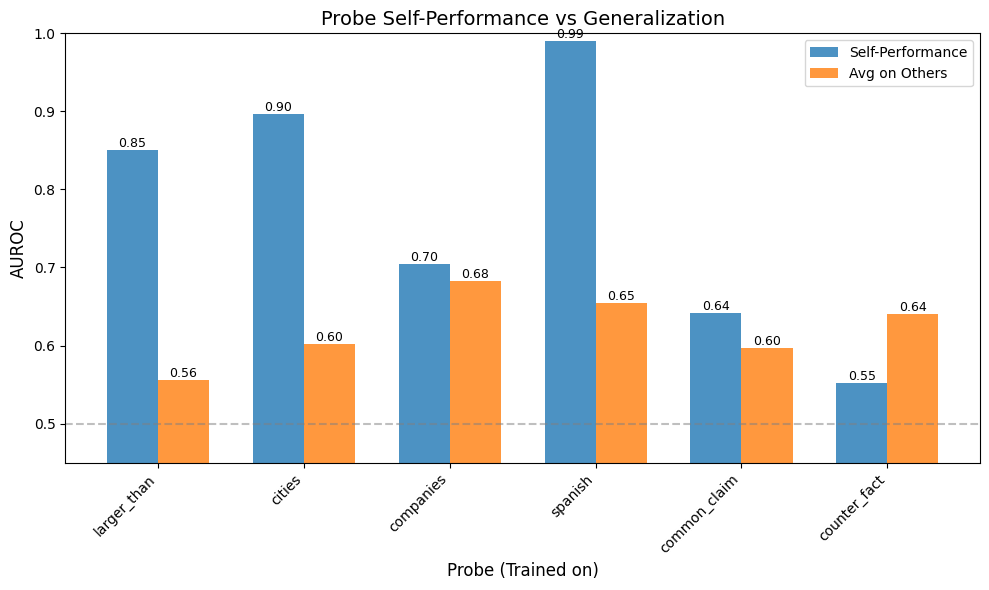


Generalization Scores:
  companies_db: 0.683
  spanish_db: 0.654
  counter_fact_db: 0.641
  cities_db: 0.602
  common_claim_db: 0.597
  larger_than_db: 0.556

3. Layer Consistency


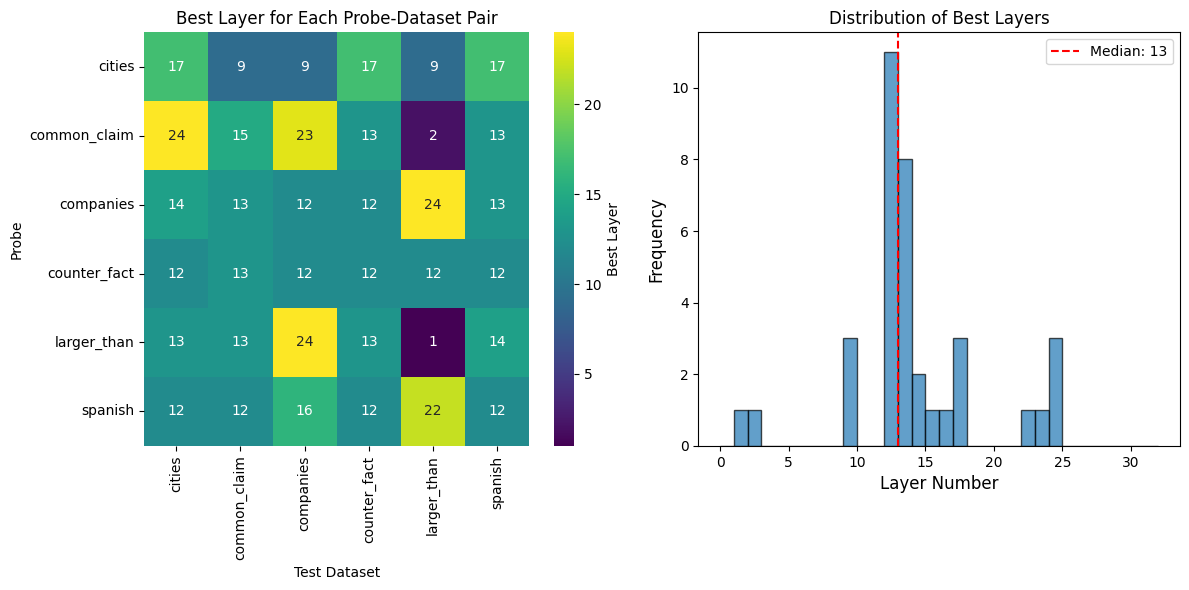


4. Transfer Asymmetry


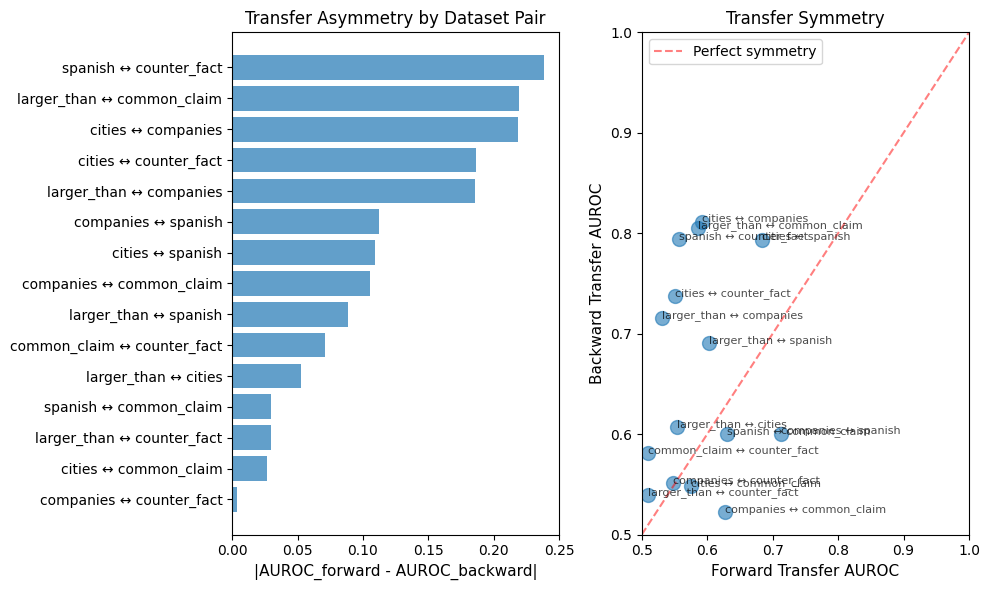


Most Asymmetric Pairs:
                          pair   forward  backward  asymmetry
13      spanish ↔ counter_fact  0.556253  0.794408   0.238155
3   larger_than ↔ common_claim  0.585404  0.804880   0.219476
5           cities ↔ companies  0.592385  0.811087   0.218702
8        cities ↔ counter_fact  0.551096  0.737685   0.186588
1      larger_than ↔ companies  0.530254  0.715599   0.185345


In [ ]:
# Individual plots
plot_generalization_heatmap(results)
plt.show()

plot_generalization_scores(results)
plt.show()

plot_layer_consistency(results)
plt.show()

plot_transfer_asymmetry(results)
plt.show()

# Or all at once
report = create_full_report(results)

In [ ]:
class LinearProbe(nn.Module):
    """Simple logistic regression probe"""
    def __init__(self, d_model):
        super().__init__()
        self.linear = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: [batch, d_model]
        return self.linear(x).squeeze(-1)  # [batch]

class LinearProbeTrainer:
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    def extract_pooled_activations(self, texts, labels, batch_size=8, pool='mean', verbose=True):
        """
        PHASE 1: Extract activations from model (batched through LLM)
        """
        # Get max length first
        all_tokens = self.tokenizer(texts, padding='longest', return_tensors='pt')
        max_len = all_tokens['input_ids'].shape[1]
        del all_tokens

        all_X = []
        all_y = []

        with torch.no_grad():
            iterator = range(0, len(texts), batch_size)
            if verbose:
                iterator = tqdm(iterator, desc='Extracting activations')

            for i in iterator:
                batch_texts = texts[i:i+batch_size]
                batch_labels = labels[i:i+batch_size]

                tokens = self.tokenizer(batch_texts, padding='max_length',
                                       max_length=max_len, return_tensors='pt')
                token_ids = tokens['input_ids'].to(self.device)

                output = self.model(token_ids, output_hidden_states=True)
                batch_acts = torch.stack(output.hidden_states, dim=0)

                if pool == 'mean':
                    pooled = batch_acts.mean(dim=2)
                elif pool == 'max':
                    pooled = batch_acts.max(dim=2)[0]

                pooled = pooled.permute(1, 0, 2)
                all_X.append(pooled.cpu().float())
                all_y.extend([1 if label in ['truth', 1] else 0 for label in batch_labels])

                del token_ids, output, batch_acts, pooled
                torch.cuda.empty_cache()

        X = torch.cat(all_X, dim=0)
        y = torch.tensor(all_y, dtype=torch.float32)

        if verbose:
            print(f"Extracted activations: {X.shape}")
        return X, y

    def fit(self, X, y, layer, n_epochs=10, batch_size=128, lr=0.001, weight_decay=0.01, verbose=False):
        """Train probe on a single layer"""
        X_layer = X[:, layer, :].to(self.device)
        y = y.to(self.device)

        dataset = TensorDataset(X_layer, y)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        d_model = X_layer.shape[1]
        probe = LinearProbe(d_model).to(self.device)

        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=weight_decay)

        probe.train()
        for epoch in range(n_epochs):
            total_loss = 0
            for X_batch, y_batch in dataloader:
                optimizer.zero_grad()
                logits = probe(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            if verbose and (epoch + 1) % 5 == 0:
                avg_loss = total_loss / len(dataloader)
                print(f"    Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")

        return probe

    def evaluate(self, probe, X, y, layer):
        """Evaluate probe on a single layer"""
        X_layer = X[:, layer, :].to(self.device)
        y_np = y.cpu().numpy()

        probe.eval()
        with torch.no_grad():
            logits = probe(X_layer)
            scores = torch.sigmoid(logits).cpu().numpy()

        auroc = roc_auc_score(y_np, scores)
        return auroc

    def train_all_layers(self, X, y, n_epochs=10, batch_size=128, lr=0.001):
        """Train probe for each layer"""
        n_layers = X.shape[1]
        probes = {}

        for layer in range(n_layers):
            print(f"  Training layer {layer}...", end='', flush=True)
            probe = self.fit(X, y, layer, n_epochs, batch_size, lr, verbose=False)
            probes[layer] = probe
            print(" Done")

        return probes


def train_and_evaluate_probes(model, tokenizer, device, train_db, datasets_dict):
    """
    Train probes on one dataset, evaluate on all datasets.
    Returns structured results like evaluate_probe_on_all_datasets.
    """
    trainer = LinearProbeTrainer(model, tokenizer, device)

    # ============ EXTRACT TRAIN ACTIVATIONS ============
    print(f"\n{'='*60}")
    print(f"Training probes on: {train_db}")
    print(f"{'='*60}")

    train_data = datasets_dict[train_db]
    print("Phase 1: Extracting train activations...")
    X_train, y_train = trainer.extract_pooled_activations(
        train_data['texts'],
        train_data['labels'],
        batch_size=8,
        verbose=True
    )

    # ============ TRAIN PROBES ============
    print("\nPhase 2: Training probes...")
    probes = trainer.train_all_layers(
        X_train,
        y_train,
        n_epochs=30,
        batch_size=128,
        lr=0.001
    )

    # Evaluate on train set to find best layer
    print("\nEvaluating on train set...")
    train_aurocs = {}
    for layer, probe in probes.items():
        auroc = trainer.evaluate(probe, X_train, y_train, layer)
        train_aurocs[layer] = auroc

    best_train_layer = max(train_aurocs, key=train_aurocs.get)
    print(f"Best train layer: {best_train_layer}, AUROC: {train_aurocs[best_train_layer]:.3f}")

    # ============ CACHE TEST ACTIVATIONS & EVALUATE ============
    print("\nPhase 3: Evaluating on all datasets...")

    # Cache activations for each test dataset
    cached_activations = {}

    results = {
        'train_dataset': train_db,
        'train_best_layer': best_train_layer,
        'train_auroc': train_aurocs[best_train_layer],
        'test_results': {}
    }

    for dataset_name in datasets_dict.keys():
        print(f"\n  Testing on {dataset_name}...")

        # Extract activations once per dataset (no verbose output)
        if dataset_name not in cached_activations:
            test_data = datasets_dict[dataset_name]
            X_test, y_test = trainer.extract_pooled_activations(
                test_data['texts'],
                test_data['labels'],
                batch_size=8,
                verbose=False  # ← No tqdm
            )
            cached_activations[dataset_name] = (X_test, y_test)
        else:
            X_test, y_test = cached_activations[dataset_name]

        # Evaluate all layers on this dataset
        layer_aurocs = {}
        for layer, probe in probes.items():
            auroc = trainer.evaluate(probe, X_test, y_test, layer)
            layer_aurocs[layer] = auroc

        # Find best layer for this dataset
        best_layer = max(layer_aurocs, key=layer_aurocs.get)
        best_auroc = layer_aurocs[best_layer]

        # Store results
        results['test_results'][dataset_name] = {
            'best_layer': best_layer,
            'auroc': best_auroc
        }

        # Print only best result
        print(f"    Best layer: {best_layer}, AUROC: {best_auroc:.3f}")

    # Clean up
    del X_train, y_train, cached_activations, probes
    torch.cuda.empty_cache()

    return results

In [ ]:
updated_keys = [key for key in datasets_dict.keys() if key !='common_claim_db' and key!= 'counter_fact_db']
datasets_dict = {key: value for key, value in datasets_dict.items() if key in updated_keys}

In [ ]:
cities_results = train_and_evaluate_probes(model, tokenizer, device, 'cities_db', datasets_dict)


Training probes on: cities_db
Phase 1: Extracting train activations...


Extracting activations: 100%|██████████| 187/187 [00:15<00:00, 11.76it/s]


Extracted activations: torch.Size([1496, 25, 896])

Phase 2: Training probes...
  Training layer 0... Done
  Training layer 1... Done
  Training layer 2... Done
  Training layer 3... Done
  Training layer 4... Done
  Training layer 5... Done
  Training layer 6... Done
  Training layer 7... Done
  Training layer 8... Done
  Training layer 9... Done
  Training layer 10... Done
  Training layer 11... Done
  Training layer 12... Done
  Training layer 13... Done
  Training layer 14... Done
  Training layer 15... Done
  Training layer 16... Done
  Training layer 17... Done
  Training layer 18... Done
  Training layer 19... Done
  Training layer 20... Done
  Training layer 21... Done
  Training layer 22... Done
  Training layer 23... Done
  Training layer 24... Done

Evaluating on train set...
Best train layer: 14, AUROC: 0.989

Phase 3: Evaluating on all datasets...

  Testing on spanish_db...
    Best layer: 12, AUROC: 0.907

  Testing on common_claim_db...
    Best layer: 12, AUROC: 0.713


In [ ]:
spanish_results = train_and_evaluate_probes(model, tokenizer, device, 'spanish_db', datasets_dict)


Training probes on: spanish_db
Phase 1: Extracting train activations...


Extracting activations: 100%|██████████| 45/45 [00:03<00:00, 14.86it/s]


Extracted activations: torch.Size([354, 25, 896])

Phase 2: Training probes...
  Training layer 0... Done
  Training layer 1... Done
  Training layer 2... Done
  Training layer 3... Done
  Training layer 4... Done
  Training layer 5... Done
  Training layer 6... Done
  Training layer 7... Done
  Training layer 8... Done
  Training layer 9... Done
  Training layer 10... Done
  Training layer 11... Done
  Training layer 12... Done
  Training layer 13... Done
  Training layer 14... Done
  Training layer 15... Done
  Training layer 16... Done
  Training layer 17... Done
  Training layer 18... Done
  Training layer 19... Done
  Training layer 20... Done
  Training layer 21... Done
  Training layer 22... Done
  Training layer 23... Done
  Training layer 24... Done

Evaluating on train set...
Best train layer: 12, AUROC: 0.992

Phase 3: Evaluating on all datasets...

  Testing on spanish_db...
    Best layer: 12, AUROC: 0.992

  Testing on common_claim_db...
    Best layer: 13, AUROC: 0.663



In [ ]:
companies_results = train_and_evaluate_probes(model, tokenizer, device, 'companies_db', datasets_dict)


Training probes on: companies_db
Phase 1: Extracting train activations...


Extracting activations: 100%|██████████| 150/150 [00:16<00:00,  8.97it/s]

Extracted activations: torch.Size([1200, 25, 896])

Phase 2: Training probes...
  Training layer 0...

 Done
  Training layer 1... Done
  Training layer 2... Done
  Training layer 3... Done
  Training layer 4... Done
  Training layer 5... Done
  Training layer 6... Done
  Training layer 7... Done
  Training layer 8... Done
  Training layer 9... Done
  Training layer 10... Done
  Training layer 11... Done
  Training layer 12... Done
  Training layer 13... Done
  Training layer 14... Done
  Training layer 15... Done
  Training layer 16... Done
  Training layer 17... Done
  Training layer 18... Done
  Training layer 19... Done
  Training layer 20... Done
  Training layer 21... Done
  Training layer 22... Done
  Training layer 23... Done
  Training layer 24... Done

Evaluating on train set...
Best train layer: 13, AUROC: 0.814

Phase 3: Evaluating on all datasets...

  Testing on spanish_db...
    Best layer: 13, AUROC: 0.916

  Testing on common_claim_db...
    Best layer: 14, AUROC: 0.679

  Testing on counter_fact_db...
    Best layer: 13, AUROC: 0.595

  Testing on larger_than_db...
   

In [ ]:
larger_than_results = train_and_evaluate_probes(model, tokenizer, device, 'larger_than_db', datasets_dict)


Training probes on: larger_than_db
Phase 1: Extracting train activations...


Extracting activations: 100%|██████████| 248/248 [00:16<00:00, 15.07it/s]

Extracted activations: torch.Size([1980, 25, 896])

Phase 2: Training probes...
  Training layer 0...

 Done
  Training layer 1... Done
  Training layer 2... Done
  Training layer 3... Done
  Training layer 4... Done
  Training layer 5... Done
  Training layer 6... Done
  Training layer 7... Done
  Training layer 8... Done
  Training layer 9... Done
  Training layer 10... Done
  Training layer 11... Done
  Training layer 12... Done
  Training layer 13... Done
  Training layer 14... Done
  Training layer 15... Done
  Training layer 16... Done
  Training layer 17... Done
  Training layer 18... Done
  Training layer 19... Done
  Training layer 20... Done
  Training layer 21... Done
  Training layer 22... Done
  Training layer 23... Done
  Training layer 24... Done

Evaluating on train set...
Best train layer: 24, AUROC: 0.998

Phase 3: Evaluating on all datasets...

  Testing on spanish_db...
    Best layer: 14, AUROC: 0.516

  Testing on common_claim_db...
    Best layer: 15, AUROC: 0.587

  Testing on counter_fact_db...
    Best layer: 14, AUROC: 0.502

  Testing on larger_than_db...
   

In [ ]:
common_claim_results = train_and_evaluate_probes(model, tokenizer, device, 'common_claim_db', datasets_dict)


Training probes on: common_claim_db
Phase 1: Extracting train activations...


Extracting activations: 100%|██████████| 557/557 [00:45<00:00, 12.17it/s]

Extracted activations: torch.Size([4450, 25, 896])

Phase 2: Training probes...
  Training layer 0...

 Done
  Training layer 1... Done
  Training layer 2... Done
  Training layer 3... Done
  Training layer 4... Done
  Training layer 5... Done
  Training layer 6... Done
  Training layer 7... Done
  Training layer 8... Done
  Training layer 9... Done
  Training layer 10... Done
  Training layer 11... Done
  Training layer 12... Done
  Training layer 13... Done
  Training layer 14... Done
  Training layer 15... Done
  Training layer 16... Done
  Training layer 17... Done
  Training layer 18... Done
  Training layer 19... Done
  Training layer 20... Done
  Training layer 21... Done
  Training layer 22... Done
  Training layer 23... Done
  Training layer 24... Done

Evaluating on train set...
Best train layer: 24, AUROC: 0.837

Phase 3: Evaluating on all datasets...

  Testing on spanish_db...
    Best layer: 12, AUROC: 0.947

  Testing on common_claim_db...
    Best layer: 24, AUROC: 0.837

  Testing on counter_fact_db...
    Best layer: 13, AUROC: 0.567

  Testing on larger_than_db...
   

In [ ]:
counter_fact_results = train_and_evaluate_probes(model, tokenizer, device, 'counter_fact_db', datasets_dict)


Training probes on: counter_fact_db
Phase 1: Extracting train activations...


Extracting activations: 100%|██████████| 3996/3996 [05:29<00:00, 12.14it/s]


Extracted activations: torch.Size([31964, 25, 896])

Phase 2: Training probes...
  Training layer 0... Done
  Training layer 1... Done
  Training layer 2... Done
  Training layer 3... Done
  Training layer 4... Done
  Training layer 5... Done
  Training layer 6... Done
  Training layer 7... Done
  Training layer 8... Done
  Training layer 9... Done
  Training layer 10... Done
  Training layer 11... Done
  Training layer 12... Done
  Training layer 13... Done
  Training layer 14... Done
  Training layer 15... Done
  Training layer 16... Done
  Training layer 17... Done
  Training layer 18... Done
  Training layer 19... Done
  Training layer 20... Done
  Training layer 21... Done
  Training layer 22... Done
  Training layer 23... Done
  Training layer 24... Done

Evaluating on train set...
Best train layer: 13, AUROC: 0.778

Phase 3: Evaluating on all datasets...

  Testing on spanish_db...
    Best layer: 13, AUROC: 0.936

  Testing on common_claim_db...
    Best layer: 12, AUROC: 0.676

In [ ]:
results = {
    'larger_than_db': larger_than_results,
    'cities_db': cities_results,
    'companies_db': companies_results,
    'spanish_db': spanish_results,
    'common_claim_db': common_claim_results,
    'counter_fact_db': counter_fact_results
}

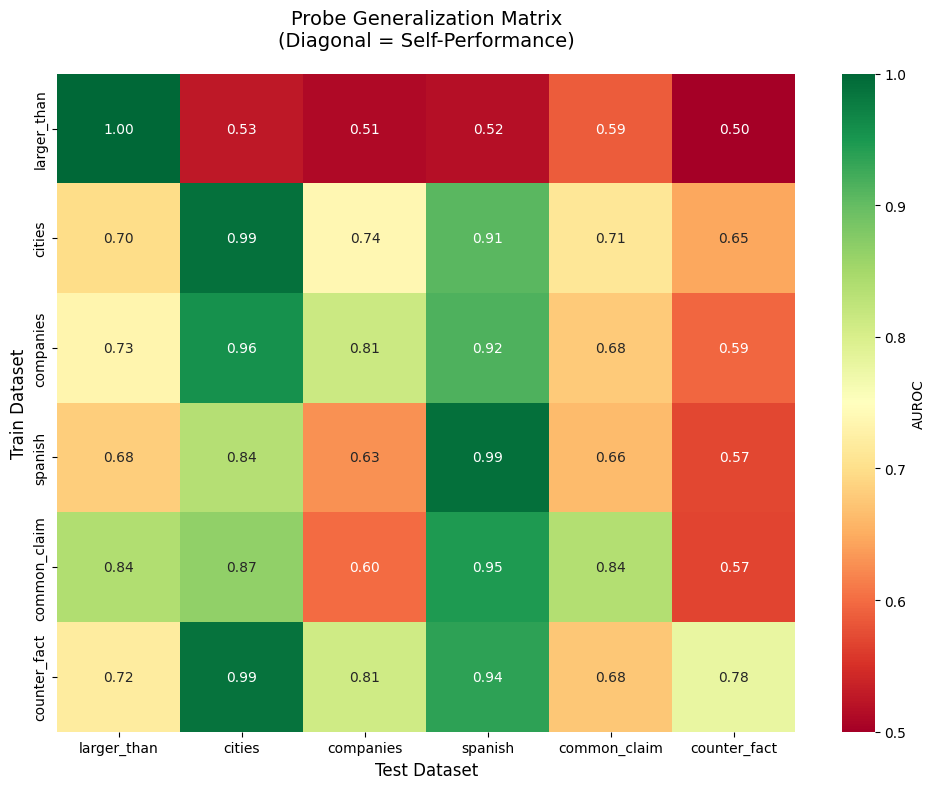

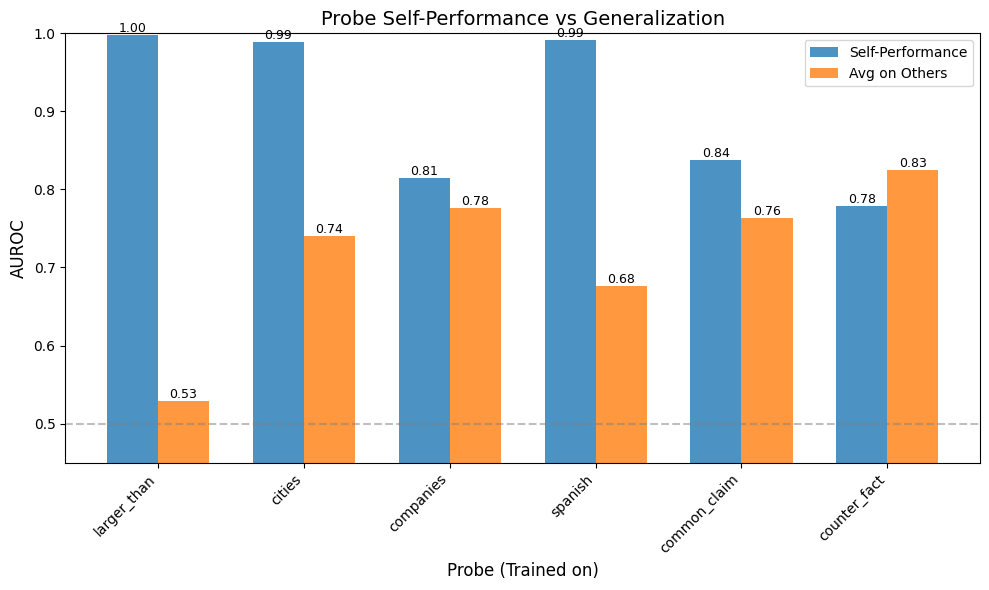

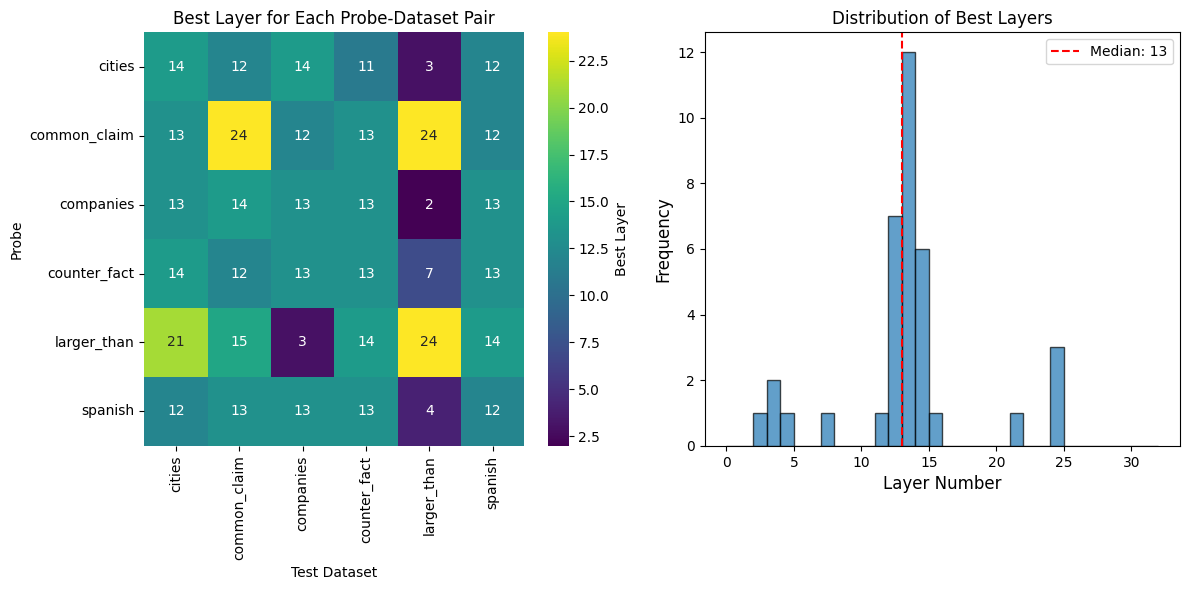

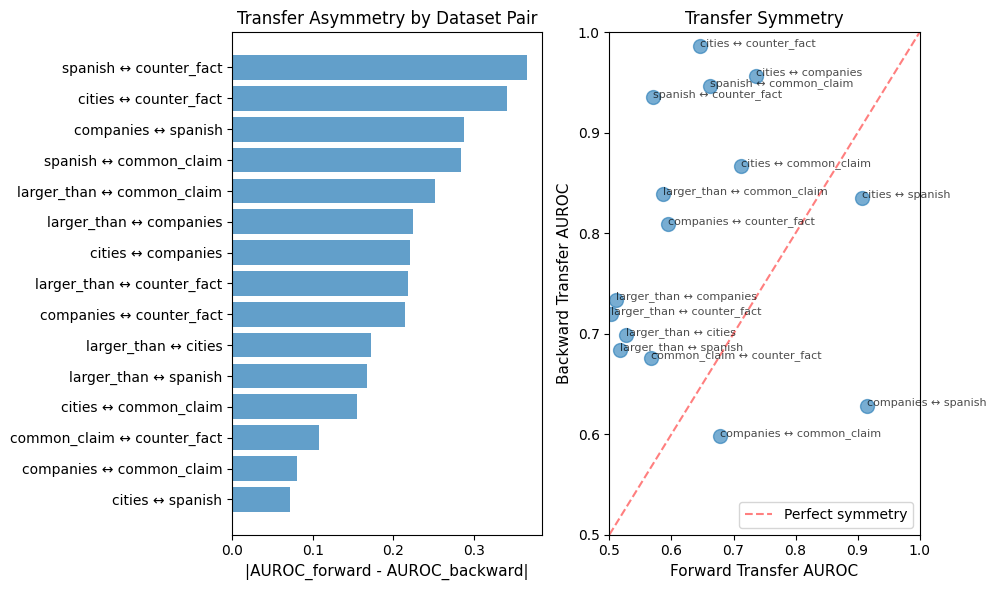

In [ ]:
plot_generalization_heatmap(results)
plt.show()

plot_generalization_scores(results)
plt.show()

plot_layer_consistency(results)
plt.show()

plot_transfer_asymmetry(results)
plt.show()
